# I want to check my understanding of COV 

### I think that at low chunksizes, there should be NO covariance (if truly uniform)

Because the values in the *positive quadrant* should cancel out values in the *negative quadrant*

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

A 1-D or 2-D array containing multiple variables and observations. Each row of m represents a variable, and each column a single observation of all those variables. Also see rowvar below.

rowvarbool, optional
If rowvar is True (default), then each row represents a variable, with observations in the columns. Otherwise, the relationship is transposed: each column represents a variable, while the rows contain observations.

# Master Functions 

In [36]:
def Plot_density(x, y):
    # concatenates the two arrays - maintaing row length
    array = np.array([x, y]) # shape : rows, columns 
    # Create a KDE density estimation object (using xy), then estimate density over xy
    z = gaussian_kde(array)(array)
    # plot 
    plt.scatter(x, y, c=z, s=100)
    plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))
    plt.show()

def Plot(x, y):
    # extract out first and second rows (TN1 and TN2) 
    # PLot a scatter plot
    plt.scatter(x, y) 
    # Plot a linear line of best fit 
    plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))
    plt.show()

def Cov(x, y):
    TN_Freq_array = np.array([x, y])
    Cov_matrix = np.cov(TN_Freq_array)
    print(Cov_matrix)
    

### Points in positive and negative quadrants cancel out

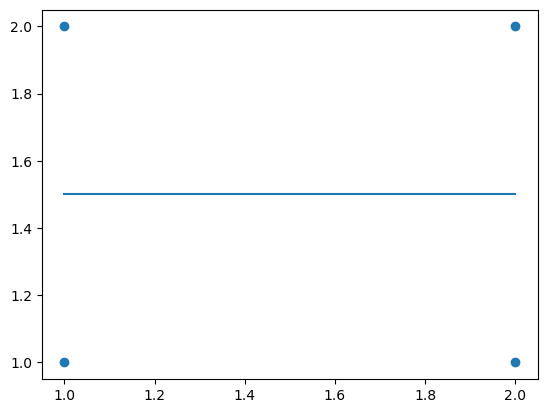

[[0.33333333 0.        ]
 [0.         0.33333333]]


In [37]:
# Create a 2D array - Each row is a different TN, each column is a differnt chunk
TN1 = [1, 1, 2, 2]
TN2 = [1, 2 , 1 ,2]

# Plot the two TN with linear regression line - building visual intuation 
Plot(TN1, TN2)

# Print the COV between the two TN 
Cov(TN1, TN2)



### Both are binomial normal = No Cov

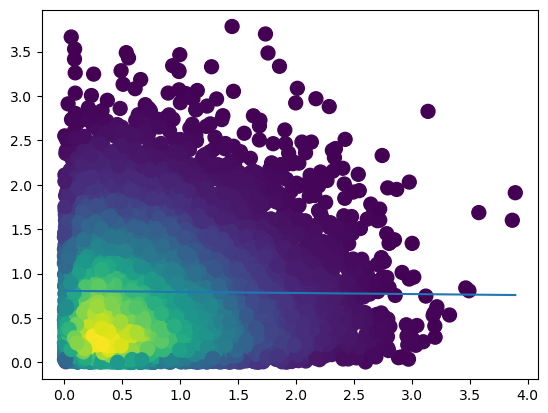

[[ 0.36176208 -0.00439677]
 [-0.00439677  0.36455331]]


In [64]:
x = abs(np.random.normal(0, 1, size = 10000))
y = abs(np.random.normal(0, 1, size = 10000))

Plot_density(x, y)

Cov(x, y)

### Both normal distribution AND with different STD = No Cov

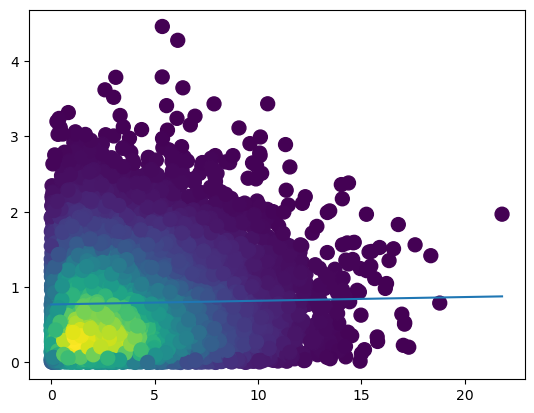

[[8.9358979  0.04389209]
 [0.04389209 0.35999416]]


In [65]:
x = abs(np.random.normal(0, 5, size = 10000))
y = abs(np.random.normal(0, 1, size = 10000))

Plot_density(x, y)

Cov(x, y)

### Both normal distribution AND with different STD AND with different mean = No Cov

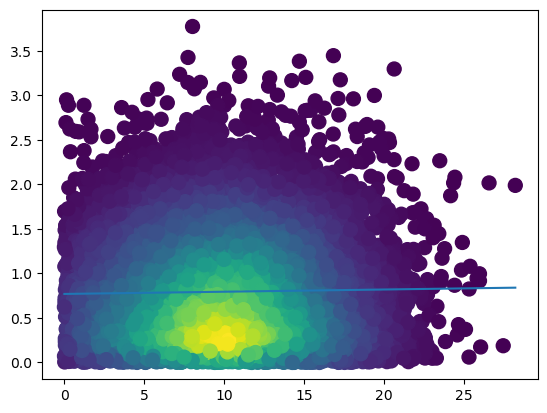

[[22.81492994  0.05691953]
 [ 0.05691953  0.35574624]]


In [66]:
x = abs(np.random.normal(10, 5, size = 10000))
y = abs(np.random.normal(0, 1, size = 10000))

Plot_density(x, y)

Cov(x, y)

### Creating Cov : mean of 20 (Cheat method of preventing negative Counts) 

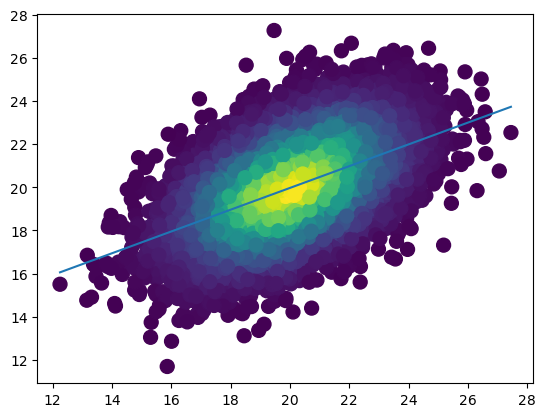

[[3.92951481 1.9844126 ]
 [1.9844126  3.96615473]]


In [74]:

mean = [20, 20]  # mean of x and y
cov = [[4, 2],  # 8 = Cov(x,y)
       [2, 4]]   # variance of y = 1

x, y = np.random.multivariate_normal(mean, cov, size=10000).T

Plot_density(x,y)
Cov(x,y)


### Cov is sensitive to variation

*Covariance increases with variation only if the relationship strength stays the same.* - meaning if the relationship is diminished (ie becomes more flat) then the number of points cancelling out in the four quadrants will increase 

*If variation increases because of noise, covariance can decrease.* - because the relationship gets flattened

*At the end of the day it is just about the residual sizes that are found within each positive and negative quadrant*

In [84]:
from scipy.stats import linregress

cov_small = [[1, 0.8],
             [0.8, 1]]
cov_large = [[4, 3.2],
             [3.2, 4]]

c = np.random.multivariate_normal([0,0], cov_small, 10000).T
x2, y2 = np.random.multivariate_normal([0,0], cov_large, 10000).T


print(np.cov(x1, y1)[0,1])  # small variation
print(np.cov(x2, y2)[0,1], "\n")  # larger variation

# But the *relationship* is identifical between them 
linregress_small_var = linregress(x1, y1)
linregress_large_var = linregress(x2, y2)

print(linregress_small_var[0])
print(linregress_large_var[0])



0.7854516159844973
3.194282074692856 

0.7912172304993118
0.7979095951134508


Look at x and y axis labels!!!


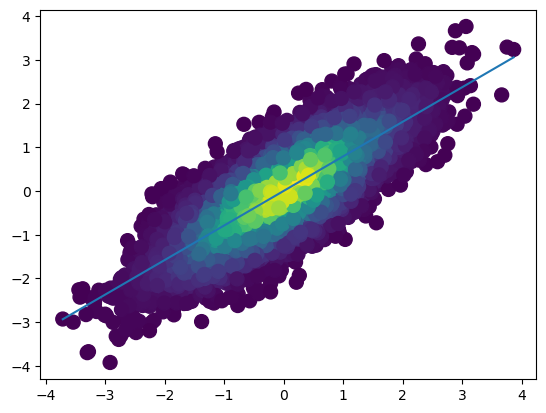

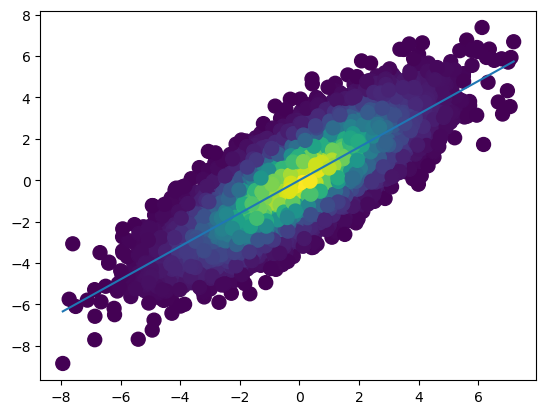

In [88]:
print("Look at x and y axis labels!!!")
Plot_density(x1, y1)
Plot_density(x2, y2)

### Cov is sensitive to scale 

In [89]:
mean = [20, 20]
cov = [[2, 1],    # Cov = 1
       [1, 2]]

x, y = np.random.multivariate_normal(mean, cov, 10000).T
print(np.cov(x, y))  # baseline covariance

# Now scale x and y
x2 = x * 2
y2 = y * 2
print(np.cov(x2, y2))  # scaled covariance


[[1.98288092 0.99435089]
 [0.99435089 2.01093853]]
[[7.93152367 3.97740355]
 [3.97740355 8.04375411]]


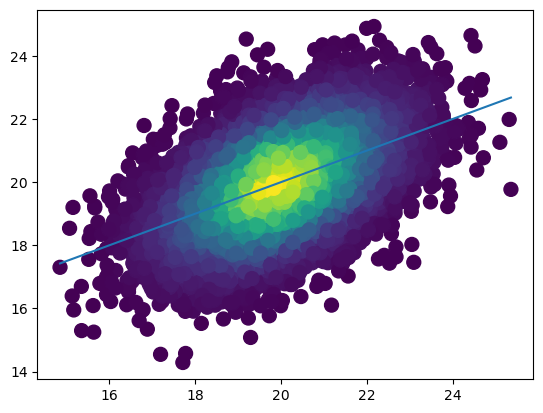

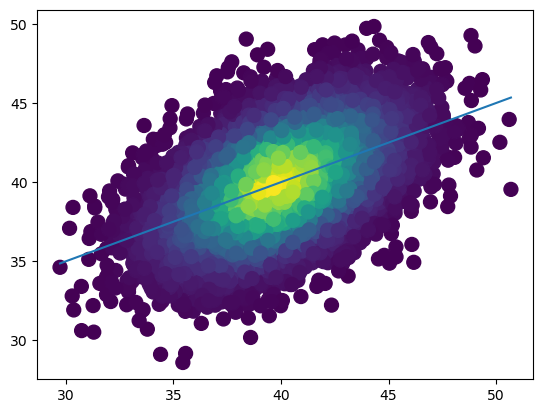

In [90]:
Plot_density(x,y)
Plot_density(x2, y2)